smartdrop company


import libraries


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import data

In [2]:
customer=pd.read_csv("messy_customers.csv")
order_items=pd.read_csv("messy_order_items.csv")
orders=pd.read_csv("messy_orders.csv")
products=pd.read_csv("messy_products.csv",encoding="latin1")

data explore

In [3]:
customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   customer_id    496 non-null    str  
 1   customer_name  469 non-null    str  
 2   city           456 non-null    str  
 3   signup_date    496 non-null    str  
dtypes: str(4)
memory usage: 16.4 KB


In [4]:
order_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 1930 entries, 0 to 1929
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_item_id  1930 non-null   int64  
 1   order_id       1930 non-null   str    
 2   product_id     1930 non-null   str    
 3   quantity       1625 non-null   float64
 4   unit_price     977 non-null    float64
dtypes: float64(2), int64(1), str(2)
memory usage: 75.5 KB


In [5]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 1176 entries, 0 to 1175
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   order_id        1121 non-null   str  
 1   customer_id     1121 non-null   str  
 2   order_date      1121 non-null   str  
 3   payment_method  993 non-null    str  
dtypes: str(4)
memory usage: 36.9 KB


In [6]:
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    90 non-null     str    
 1   product_name  90 non-null     str    
 2   category      90 non-null     str    
 3   base_price    33 non-null     float64
dtypes: float64(1), str(3)
memory usage: 2.9 KB


customer


In [7]:
customer.isnull().sum()

customer_id      24
customer_name    51
city             64
signup_date      24
dtype: int64

In [8]:
customer['customer_name']=customer['customer_name'].fillna("unknown")


In [9]:
customer['customer_name'].str.capitalize()

0      Customer_1
1      Customer_2
2      Customer_3
3      Customer_4
4         Unknown
          ...    
515       Unknown
516       Unknown
517       Unknown
518       Unknown
519       Unknown
Name: customer_name, Length: 520, dtype: str

In [10]:
customer['city']=customer['city'].fillna("Not Found")

In [11]:
customer["city"].value_counts()

city
Not Found    64
Hyderabad    51
delhi        50
Pune         47
Mumbai       47
DELHI        43
Bangalore    41
Kolkata      40
mumbai       38
Delhi        37
Chennai      34
Bengaluru    28
Name: count, dtype: int64

In [12]:
customer["city"]=customer["city"].replace("DELHI","Delhi")

In [13]:
customer["city"]=customer["city"].replace("delhi","Delhi")

In [14]:
customer["city"]=customer["city"].replace("Bangalore","Bengaluru")

In [15]:
customer["city"]=customer['city'].str.title()

In [16]:
customer.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
515     True
516     True
517     True
518     True
519     True
Length: 520, dtype: bool

In [17]:
customer.drop_duplicates(inplace=True)

In [18]:
customer["signup_date"]

0      09-02-2024
1      20-04-2025
2      19-08-2024
3      08-08-2023
4      04-03-2024
          ...    
492    25-12-2023
493    30-03-2024
494    21-01-2025
495    01-01-2023
496           NaN
Name: signup_date, Length: 497, dtype: str

In [19]:
customer['signup_date']=pd.to_datetime(customer['signup_date'],format="mixed")

order_items

In [20]:
order_items.isnull().sum()

order_item_id      0
order_id           0
product_id         0
quantity         305
unit_price       953
dtype: int64

In [21]:
order_items["quantity"]=order_items["quantity"].fillna(1)

In [22]:
order_items["quantity"]=order_items["quantity"].replace({'0':'1'})

In [23]:
avg=order_items["unit_price"].mean()
print(round(avg))


44755


In [24]:
order_items["unit_price"]=order_items["unit_price"].fillna(44956)

In [25]:
order_items.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1925    False
1926    False
1927    False
1928    False
1929    False
Length: 1930, dtype: bool

products

In [26]:
products.isnull().sum()

product_id       0
product_name     0
category         0
base_price      57
dtype: int64

In [27]:
products['category'].value_counts()

category
smart phone    17
Tablet         16
laptop         13
Accessory      12
Smartphone     11
Accessories    11
tablet          5
Laptop          5
Name: count, dtype: int64

In [28]:
products['category']=products['category'].replace({"Accessory":"Accessories"})
products['category']=products['category'].replace({"Smart phone":"Smartphone"})

In [29]:
products["category"]=products["category"].str.capitalize()

In [30]:
mean=products['base_price'].mean()
print(round(mean))

45047


In [31]:
products['base_price']=products['base_price'].fillna(45047)

In [32]:
products.duplicated()

0     False
1     False
2     False
3     False
4     False
      ...  
85     True
86     True
87     True
88     True
89     True
Length: 90, dtype: bool

In [33]:
products.drop_duplicates(inplace=True)

orders


In [34]:
orders.isnull().sum()

order_id           55
customer_id        55
order_date         55
payment_method    183
dtype: int64

In [35]:
orders['payment_method']=orders['payment_method'].fillna('Notfound')

In [36]:
orders['payment_method'].value_counts()

payment_method
Notfound            183
Cash                155
Credit Card         152
UPI                 145
upi                 144
credit card         137
Cash on Delivery    134
Debit Card          126
Name: count, dtype: int64

In [37]:
orders['payment_method']=orders['payment_method'].str.title()

In [38]:
orders['payment_method']=orders['payment_method'].replace({'Cash On Delivery':'Cash'})

In [39]:
orders.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1171     True
1172     True
1173     True
1174     True
1175     True
Length: 1176, dtype: bool

In [40]:
orders=orders.drop_duplicates()

In [41]:
orders['order_date']=pd.to_datetime(orders['order_date'],format='mixed')

Data Transformation

In [42]:
#orders['month']

In [43]:
orders['month']=orders['order_date'].dt.month_name()

In [44]:
orders['year']=orders['order_date'].dt.year

In [45]:
orders['month_no']=orders['order_date'].dt.month

In [46]:
orders['quater']=orders['order_date'].dt.quarter

In [47]:
customer['month']=customer['signup_date'].dt.month_name()

In [48]:
customer['year']=customer['signup_date'].dt.year

In [49]:
customer['quater']=customer['signup_date'].dt.quarter

In [50]:
#pd.merge(customer,orders,on='customer_id',how="right")

insight 

In [51]:
order_items['amount']=order_items['quantity']*order_items['unit_price']

In [52]:
customer

,customer_id,customer_name,city,signup_date,month,year,quater
0,C0001,Customer_1,Delhi,2024-09-02,September,2024.0,3.0
1,C0002,Customer_2,Delhi,2025-04-20,April,2025.0,2.0
2,C0003,Customer_3,Bengaluru,2024-08-19,August,2024.0,3.0
3,C0004,Customer_4,Pune,2023-08-08,August,2023.0,3.0
4,C0005,unknown,Bengaluru,2024-04-03,April,2024.0,2.0
...,...,...,...,...,...,...,...
492,C0493,Customer_493,Pune,2023-12-25,December,2023.0,4.0
493,C0494,Customer_494,Chennai,2024-03-30,March,2024.0,1.0
494,C0495,Customer_495,Pune,2025-01-21,January,2025.0,1.0
495,C0496,Customer_496,Delhi,2023-01-01,January,2023.0,1.0


In [53]:
#totalRevenue
total_revenue=order_items['quantity']*order_items['unit_price']
print(f"The total revenue is {sum(total_revenue)}")


The total revenue is 158513136.0


In [54]:
mix=products.merge(order_items,on='product_id')
print(mix)

     product_id    product_name category  base_price  order_item_id order_id  \
0          P001  Lenovo IdeaPad   Tablet     28151.0            228   O00862   
1          P001  Lenovo IdeaPad   Tablet     28151.0            427   O00610   
2          P001  Lenovo IdeaPad   Tablet     28151.0            618   O00343   
3          P001  Lenovo IdeaPad   Tablet     28151.0            634   O00485   
4          P001  Lenovo IdeaPad   Tablet     28151.0            662   O01127   
...         ...             ...      ...         ...            ...      ...   
1925       P080         OnePlus   Laptop     82478.0           1595   O00405   
1926       P080         OnePlus   Laptop     82478.0           1662   O01122   
1927       P080         OnePlus   Laptop     82478.0           1695   O00412   
1928       P080         OnePlus   Laptop     82478.0           1814   O00575   
1929       P080         OnePlus   Laptop     82478.0           1872   O00288   

      quantity  unit_price    amount  


In [55]:
mix['category']=mix['category'].replace({"Smart phone":"Smartphone"})

In [56]:
#top product base on quantity
top_qty=mix.groupby('category')["quantity"].sum()
print(f'The top product according to qty is {top_qty}')


The top product according to qty is category
Accessories     897.0
Laptop          670.0
Smartphone     1144.0
Tablet          824.0
Name: quantity, dtype: float64


In [57]:
#top category base on revenue
top_product=mix.groupby('category')['amount'].sum()
print(top_product)



category
Accessories    40712165.0
Laptop         29477610.0
Smartphone     50735746.0
Tablet         37587615.0
Name: amount, dtype: float64


In [58]:
#which payment method pefer by customer the most 
PaymentMethod=orders.groupby('payment_method')['order_id'].count().sort_values()
print(PaymentMethod)

payment_method
Debit Card     126
Notfound       128
Credit Card    289
Cash           289
Upi            289
Name: order_id, dtype: int64


In [59]:
#total_order=order_items.merge(orders,on='order_id')

In [60]:
Data=customer.merge(orders,on='customer_id').merge(order_items,on='order_id').merge(products,on='product_id')

In [80]:
Data

,customer_id,customer_name,city,signup_date,month_x,year_x,quater_x,order_id,order_date,payment_method,...,month_no,quater_y,order_item_id,product_id,quantity,unit_price,amount,product_name,category,base_price
0,C0001,Customer_1,Delhi,2024-09-02,September,2024.0,3.0,O00309,2024-02-27,Debit Card,...,2.0,1.0,124,P033,2.0,44956.0,89912.0,Wireless Mouse,Laptop,47453.0
1,C0001,Customer_1,Delhi,2024-09-02,September,2024.0,3.0,O00309,2024-02-27,Debit Card,...,2.0,1.0,235,P070,4.0,35845.0,143380.0,iPad Air,Tablet,45047.0
2,C0001,Customer_1,Delhi,2024-09-02,September,2024.0,3.0,O00309,2024-02-27,Debit Card,...,2.0,1.0,397,P064,3.0,44956.0,134868.0,Lenovo IdeaPad,Accessories,81129.0
3,C0001,Customer_1,Delhi,2024-09-02,September,2024.0,3.0,O00309,2024-02-27,Debit Card,...,2.0,1.0,719,P029,4.0,44956.0,179824.0,Samsung Galaxy,Accessories,45047.0
4,C0001,Customer_1,Delhi,2024-09-02,September,2024.0,3.0,O00309,2024-02-27,Debit Card,...,2.0,1.0,1206,P060,0.0,28975.0,0.0,USB Hub,Laptop,45047.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1784,C0496,Customer_496,Delhi,2023-01-01,January,2023.0,1.0,O00860,2025-01-16,Cash,...,1.0,1.0,818,P010,0.0,44956.0,0.0,iPhone 13,Smart phone,45047.0
1785,C0496,Customer_496,Delhi,2023-01-01,January,2023.0,1.0,O00860,2025-01-16,Cash,...,1.0,1.0,1223,P033,1.0,39720.0,39720.0,Wireless Mouse,Laptop,47453.0
1786,C0496,Customer_496,Delhi,2023-01-01,January,2023.0,1.0,O01012,2024-08-16,Upi,...,8.0,3.0,116,P064,0.0,87243.0,0.0,Lenovo IdeaPad,Accessories,81129.0
1787,C0496,Customer_496,Delhi,2023-01-01,January,2023.0,1.0,O01012,2024-08-16,Upi,...,8.0,3.0,1414,P047,1.0,44956.0,44956.0,OnePlus,Smart phone,45047.0


In [62]:
Data['year_y']

0       2024.0
1       2024.0
2       2024.0
3       2024.0
4       2024.0
         ...  
1784    2025.0
1785    2025.0
1786    2024.0
1787    2024.0
1788    2024.0
Name: year_y, Length: 1789, dtype: float64

In [63]:
#Total revenue by year
year=Data.groupby('year_y')['amount'].sum()
print(year)

year_y
2024.0    107541966.0
2025.0     39898182.0
Name: amount, dtype: float64


In [64]:
#Total revenue per month
month_rev=Data.groupby('month_y')['amount'].sum().sort_values()
print(month_rev)

month_y
August        7542702.0
September     7716546.0
December      9582109.0
November      9812153.0
July          9858665.0
October      10014143.0
June         11630861.0
May          12656528.0
April        15332959.0
February     15504481.0
March        18846246.0
January      18942755.0
Name: amount, dtype: float64


In [65]:
quater_rev=Data.groupby("quater_y")['amount'].sum().sort_values()
print(quater_rev)


quater_y
3.0    25117913.0
4.0    29408405.0
2.0    39620348.0
1.0    53293482.0
Name: amount, dtype: float64


In [66]:
#top city by revenue
Top_city=Data.groupby('city')['amount'].sum().sort_values()
print(Top_city)

city
Chennai       8581205.0
Kolkata       9169649.0
Not Found    12316435.0
Pune         12657457.0
Bengaluru    18983293.0
Hyderabad    20156773.0
Mumbai       22923496.0
Delhi        42651840.0
Name: amount, dtype: float64


In [91]:
#signup date
signup=Data.groupby('year_x')['customer_id'].count()
print(signup)

year_x
2023.0    707
2024.0    768
2025.0    314
Name: customer_id, dtype: int64


reports

In [67]:
orders

,order_id,customer_id,order_date,payment_method,month,year,month_no,quater
0,O00001,C0058,2024-09-05,Cash,September,2024.0,9.0,3.0
1,O00002,C0410,2024-01-02,Upi,January,2024.0,1.0,1.0
2,O00003,C0429,2025-04-13,Cash,April,2025.0,4.0,2.0
3,O00004,C0272,2024-02-25,Debit Card,February,2024.0,2.0,1.0
4,O00005,C0411,2025-04-26,Credit Card,April,2025.0,4.0,2.0
...,...,...,...,...,...,...,...,...
1117,O01118,C0055,2024-11-04,Credit Card,November,2024.0,11.0,4.0
1118,O01119,C0361,2024-11-22,Credit Card,November,2024.0,11.0,4.0
1119,O01120,C0266,2025-02-21,Upi,February,2025.0,2.0,1.0
1120,O01121,C0456,2024-01-09,Upi,January,2024.0,1.0,1.0


Text(0.5, 1.0, 'Payment method use by customer')

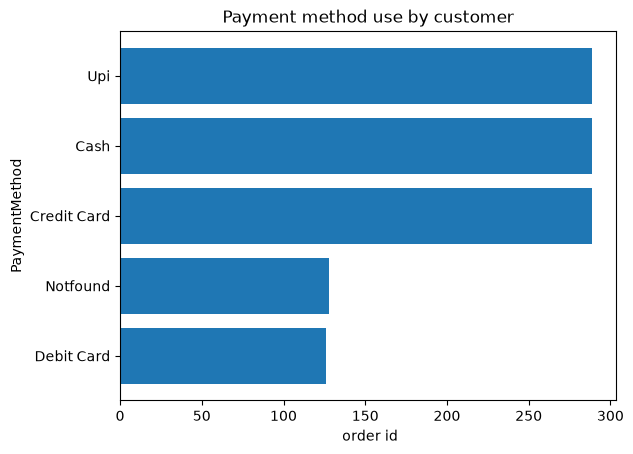

In [76]:
#PAYMENT METHOD
plt.barh(PaymentMethod.index,PaymentMethod.values)
plt.ylabel('PaymentMethod')
plt.xlabel(' order id')
plt.title('Payment method use by customer')

<Axes: xlabel='category', ylabel='amount'>

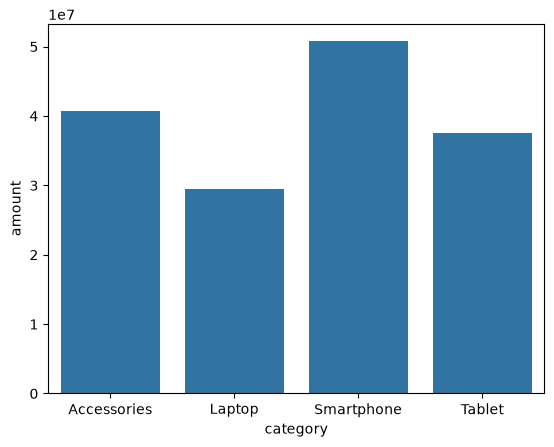

In [77]:
#TOP_PRODUCTS BASE ON REVENUE

sns.barplot(top_product)



Text(0.5, 1.0, 'Quater Revenue ')

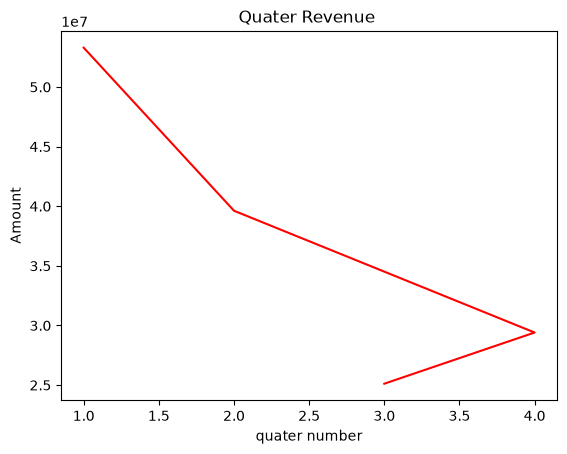

In [70]:
#Per quater revenue
plt.plot(quater_rev.index,quater_rev.values,color='red')
plt.ylabel('Amount')
plt.xlabel('quater number')
plt.title('Quater Revenue ')

Text(0.5, 1.0, 'Monthly Revenue')

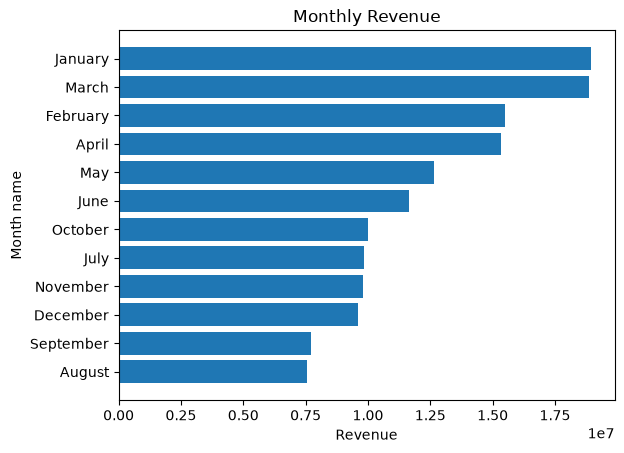

In [71]:
#Monthly revenue

plt.barh(month_rev.index,month_rev.values)
plt.xlabel('Revenue')
plt.ylabel('Month name')
plt.title('Monthly Revenue')

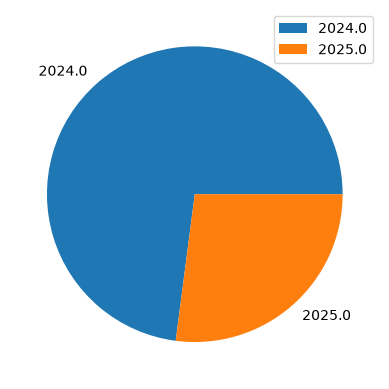

In [72]:
#Yearly revenue
plt.pie(year,labels=year.index)
plt.legend()
plt.show()

Text(0.5, 1.0, 'Total Quantity Sold')

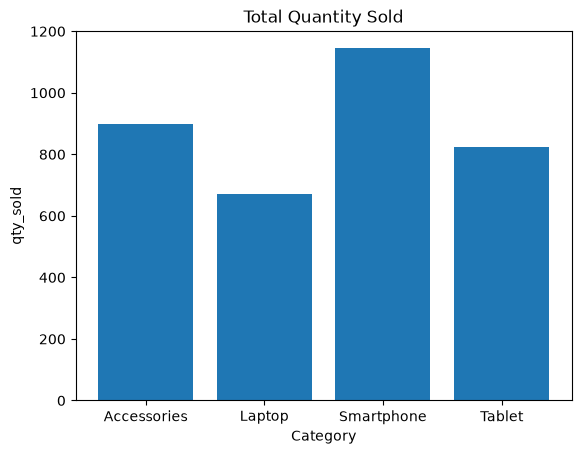

In [73]:
#top quantity sold
plt.bar(top_qty.index,top_qty.values)
plt.xlabel('Category')
plt.ylabel('qty_sold')
plt.title('Total Quantity Sold')

Text(0.5, 1.0, 'city revenue')

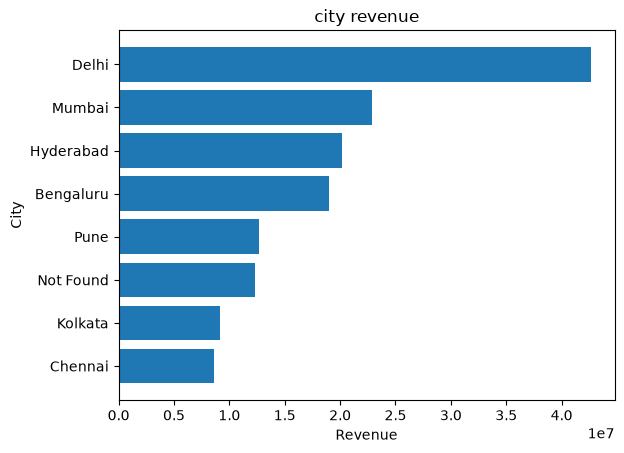

In [74]:
#revenue generated by per city
plt.barh(Top_city.index,Top_city.values)
plt.xlabel('Revenue')
plt.ylabel('City')
plt.title('city revenue')

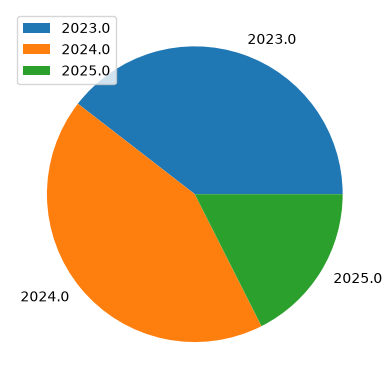

In [88]:
#per year signup by customer
plt.pie(signup,labels=signup.index)
plt.legend()
plt.show()